In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/synthea/synthea_clinical_notes.csv
/kaggle/input/synthea-cleaned/synthea_clinical_notes_clean.csv
/kaggle/input/syhthea-predictions/synthea_predictions/qwen_predictions.csv
/kaggle/input/syhthea-predictions/synthea_predictions/biomistral_predictions.csv
/kaggle/input/syhthea-predictions/synthea_predictions/mistral_predictions.csv
/kaggle/input/syhthea-predictions/synthea_predictions/gemma_predictions.csv


In [2]:
# CELL 1: Setup and Load Ground Truth
# ====================================================================

import pandas as pd
import ast
import numpy as np
import re
from collections import defaultdict

print("="*70)
print("SYNTHEA EVALUATION - MATCHING MEMBER A's METHODOLOGY")
print("="*70)

# Load ground truth (cleaned Synthea notes)
GOLD_PATH = "/kaggle/input/synthea-cleaned/synthea_clinical_notes_clean.csv"
gold_df = pd.read_csv(GOLD_PATH)

print(f"\n✓ Loaded ground truth: {len(gold_df)} notes")
print(f"  Columns: {gold_df.columns.tolist()}")

# Parse ground truth symptoms
gold_df['gold'] = gold_df['ground_truth_symptoms'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Keep only what we need
gold_df = gold_df[['note_id', 'gold']].copy()

print(f"\nSample gold standard:")
print(gold_df.head(2))

SYNTHEA EVALUATION - MATCHING MEMBER A's METHODOLOGY

✓ Loaded ground truth: 500 notes
  Columns: ['note_id', 'condition', 'ground_truth_symptoms', 'clinical_note']

Sample gold standard:
                                note_id                                  gold
0  0e15d8ce-140b-4aa2-bdf6-4c78942dec4b  [fever, headache, cough, chest pain]
1  645cb62e-f0b4-42d5-acbb-df412d7fe071              [facial pressure, cough]


In [3]:
# CELL 2: Load Model Predictions
# ====================================================================

PRED_DIR = "/kaggle/input/syhthea-predictions/synthea_predictions"  # Note: you have a typo "syhthea"

MODEL_FILES = {
    "mistral": f"{PRED_DIR}/mistral_predictions.csv",
    "gemma": f"{PRED_DIR}/gemma_predictions.csv",
    "biomistral": f"{PRED_DIR}/biomistral_predictions.csv",
    "qwen": f"{PRED_DIR}/qwen_predictions.csv"
}

all_predictions = {}

for model_name, file_path in MODEL_FILES.items():
    print(f"\nLoading {model_name}...")
    df = pd.read_csv(file_path)
    
    print(f"  Columns: {df.columns.tolist()}")
    print(f"  Rows: {len(df)}")
    
    # Parse predicted symptoms
    if 'predicted_symptoms' in df.columns:
        df['predictions'] = df['predicted_symptoms'].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x
        )
    else:
        print(f"  ⚠️ No 'predicted_symptoms' column - checking alternatives...")
        # Try to find the prediction column
        pred_cols = [c for c in df.columns if 'pred' in c.lower() or 'symptom' in c.lower()]
        if pred_cols:
            print(f"  Using column: {pred_cols[0]}")
            df['predictions'] = df[pred_cols[0]].apply(
                lambda x: ast.literal_eval(x) if isinstance(x, str) else x
            )
    
    # Keep only necessary columns
    df = df[['note_id', 'predictions']].copy()
    
    all_predictions[model_name] = df
    print(f"  ✓ Loaded {len(df)} predictions")

print("\n✓ All model predictions loaded")


Loading mistral...
  Columns: ['note_id', 'model', 'predicted_symptoms', 'raw_output']
  Rows: 500
  ✓ Loaded 500 predictions

Loading gemma...
  Columns: ['note_id', 'model', 'predicted_symptoms', 'raw_output']
  Rows: 500
  ✓ Loaded 500 predictions

Loading biomistral...
  Columns: ['note_id', 'model', 'predicted_symptoms', 'raw_output']
  Rows: 500
  ✓ Loaded 500 predictions

Loading qwen...
  Columns: ['note_id', 'model', 'predicted_symptoms', 'raw_output']
  Rows: 500
  ✓ Loaded 500 predictions

✓ All model predictions loaded


In [4]:
# CELL 3: Normalization Function (MATCHING MEMBER A's APPROACH)
# ====================================================================

def normalize(text):
    """
    Normalize symptom text for matching.
    Matches Member A's normalization approach.
    """
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)  # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()   # Normalize whitespace
    
    return text

# Test normalization
test_cases = ["Chest Pain", "shortness-of-breath", "  Difficulty  breathing  "]
print("Normalization tests:")
for test in test_cases:
    print(f"  '{test}' → '{normalize(test)}'")

Normalization tests:
  'Chest Pain' → 'chest pain'
  'shortness-of-breath' → 'shortness of breath'
  '  Difficulty  breathing  ' → 'difficulty breathing'


In [5]:
# CELL 4: Per-Note Evaluation (MATCHING MEMBER A's EXACT LOGIC)
# ====================================================================

def evaluate_note(predictions, gold_symptoms):
    """
    Evaluate a single note using Member A's exact matching logic.
    
    Returns: dict with tp, fp, fn, precision, recall, f1
    """
    # Normalize and filter
    preds_norm = set(normalize(p) for p in predictions if p != 'none')
    preds_norm = {p for p in preds_norm if p}  # Remove empty
    
    golds_norm = set(normalize(g) for g in gold_symptoms)
    golds_norm = {g for g in golds_norm if g}  # Remove empty
    
    # Calculate metrics using Member A's substring matching
    # A prediction matches if it's a substring of gold or vice versa
    tp = 0
    for pred in preds_norm:
        if any(pred in gold or gold in pred for gold in golds_norm):
            tp += 1
    
    fp = len(preds_norm) - tp
    fn = len(golds_norm) - tp
    
    # Calculate metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

# Test the function
test_gold = ['chest pain', 'shortness of breath']
test_pred = ['chest pain', 'cough']
result = evaluate_note(test_pred, test_gold)
print("\nEvaluation test:")
print(f"  Gold: {test_gold}")
print(f"  Predicted: {test_pred}")
print(f"  Result: {result}")


Evaluation test:
  Gold: ['chest pain', 'shortness of breath']
  Predicted: ['chest pain', 'cough']
  Result: {'tp': 1, 'fp': 1, 'fn': 1, 'precision': 0.5, 'recall': 0.5, 'f1': 0.5}


In [6]:
# CELL 5: Evaluate All Models (Per-Note)
# ====================================================================

per_note_results = {}
aggregate_results = []

for model_name, pred_df in all_predictions.items():
    print(f"\n{'='*70}")
    print(f"Evaluating {model_name.upper()}")
    print(f"{'='*70}")
    
    # Merge with gold standard
    merged = pred_df.merge(gold_df, on='note_id', how='inner')
    
    print(f"  Matched {len(merged)}/{len(pred_df)} notes with gold standard")
    
    if len(merged) < len(pred_df):
        print(f"  ⚠️ Warning: {len(pred_df) - len(merged)} notes have no gold standard")
    
    # Evaluate each note
    results = []
    for _, row in merged.iterrows():
        metrics = evaluate_note(row['predictions'], row['gold'])
        metrics['note_id'] = row['note_id']
        results.append(metrics)
    
    # Create per-note DataFrame
    per_note_df = pd.DataFrame(results)
    per_note_results[model_name] = per_note_df
    
    # Calculate aggregate metrics
    mean_precision = per_note_df['precision'].mean()
    mean_recall = per_note_df['recall'].mean()
    mean_f1 = per_note_df['f1'].mean()
    total_tp = per_note_df['tp'].sum()
    total_fp = per_note_df['fp'].sum()
    total_fn = per_note_df['fn'].sum()
    
    aggregate_results.append({
        'Model': model_name,
        'Precision': mean_precision,
        'Recall': mean_recall,
        'F1': mean_f1,
        'TP': total_tp,
        'FP': total_fp,
        'FN': total_fn
    })
    
    print(f"\n  Results:")
    print(f"    Precision: {mean_precision:.4f}")
    print(f"    Recall:    {mean_recall:.4f}")
    print(f"    F1:        {mean_f1:.4f}")
    print(f"    Total TP:  {total_tp}")
    print(f"    Total FP:  {total_fp}")
    print(f"    Total FN:  {total_fn}")

# Create summary DataFrame
summary_df = pd.DataFrame(aggregate_results)
summary_df = summary_df.sort_values('F1', ascending=False).reset_index(drop=True)

print(f"\n{'='*70}")
print("FINAL RESULTS - ALL MODELS")
print(f"{'='*70}")
print(summary_df.to_string(index=False))


Evaluating MISTRAL
  Matched 500/500 notes with gold standard

  Results:
    Precision: 0.3549
    Recall:    0.3634
    F1:        0.3444
    Total TP:  597
    Total FP:  1221
    Total FN:  1102

Evaluating GEMMA
  Matched 500/500 notes with gold standard

  Results:
    Precision: 0.1843
    Recall:    0.3997
    F1:        0.1597
    Total TP:  561
    Total FP:  4510
    Total FN:  1138

Evaluating BIOMISTRAL
  Matched 500/500 notes with gold standard

  Results:
    Precision: 0.7093
    Recall:    0.2489
    F1:        0.3466
    Total TP:  375
    Total FP:  612
    Total FN:  1324

Evaluating QWEN
  Matched 500/500 notes with gold standard

  Results:
    Precision: 0.1599
    Recall:    0.3792
    F1:        0.1398
    Total TP:  511
    Total FP:  5050
    Total FN:  1188

FINAL RESULTS - ALL MODELS
     Model  Precision   Recall       F1  TP   FP   FN
biomistral   0.709319 0.248900 0.346611 375  612 1324
   mistral   0.354926 0.363400 0.344440 597 1221 1102
     gemma   

In [7]:
# CELL 6: Save Results (MATCHING MEMBER A's FILE STRUCTURE)
# ====================================================================

import os

OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"\n{'='*70}")
print("SAVING RESULTS")
print(f"{'='*70}")

# Save per-note metrics (one file per model, like Member A)
for model_name, per_note_df in per_note_results.items():
    output_file = f"{OUTPUT_DIR}/{model_name}_per_note_metrics.csv"
    per_note_df.to_csv(output_file, index=False)
    print(f"✓ Saved: {output_file}")

# Save aggregate summary (like Member A's model_performance_summary.csv)
summary_output = f"{OUTPUT_DIR}/synthea_model_performance_summary.csv"
summary_df.to_csv(summary_output, index=False)
print(f"✓ Saved: {summary_output}")

# Save formatted table (like Member A's table1)
table1 = summary_df.copy()
table1['Precision'] = table1['Precision'].apply(lambda x: f"{x:.3f}")
table1['Recall'] = table1['Recall'].apply(lambda x: f"{x:.3f}")
table1['F1'] = table1['F1'].apply(lambda x: f"{x:.3f}")
table1['TP'] = table1['TP'].astype(int)
table1['FP'] = table1['FP'].astype(int)
table1['FN'] = table1['FN'].astype(int)

table1_output = f"{OUTPUT_DIR}/table_synthea_performance.csv"
table1.to_csv(table1_output, index=False)
print(f"✓ Saved: {table1_output}")

print(f"\n{'='*70}")
print("EVALUATION COMPLETE")
print(f"{'='*70}")

print("\nFiles created (matching Member A's structure):")
print("  - {model}_per_note_metrics.csv (4 files)")
print("  - synthea_model_performance_summary.csv")
print("  - table_synthea_performance.csv")


SAVING RESULTS
✓ Saved: /kaggle/working/mistral_per_note_metrics.csv
✓ Saved: /kaggle/working/gemma_per_note_metrics.csv
✓ Saved: /kaggle/working/biomistral_per_note_metrics.csv
✓ Saved: /kaggle/working/qwen_per_note_metrics.csv
✓ Saved: /kaggle/working/synthea_model_performance_summary.csv
✓ Saved: /kaggle/working/table_synthea_performance.csv

EVALUATION COMPLETE

Files created (matching Member A's structure):
  - {model}_per_note_metrics.csv (4 files)
  - synthea_model_performance_summary.csv
  - table_synthea_performance.csv


/tmp/ipykernel_55/3495961370.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='Model', y='F1', palette='viridis')


✓ Saved: synthea_f1_scores.png


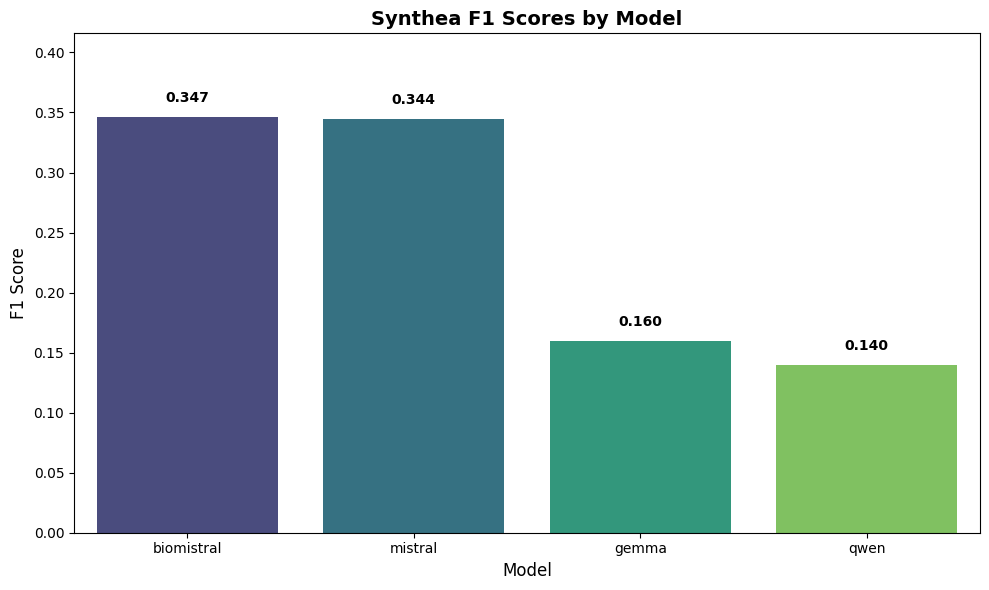


Model Ranking (by F1):
  1. biomistral: F1 = 0.347
  2. mistral: F1 = 0.344
  3. gemma: F1 = 0.160
  4. qwen: F1 = 0.140


In [8]:
# CELL 7: Quick Visualization
# ====================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Convert back to numeric for plotting
plot_df = summary_df.copy()

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x='Model', y='F1', palette='viridis')
plt.title('Synthea F1 Scores by Model', fontsize=14, fontweight='bold')
plt.ylabel('F1 Score', fontsize=12)
plt.xlabel('Model', fontsize=12)

# Add value labels
for i, row in plot_df.iterrows():
    plt.text(i, row['F1'] + 0.01, f"{row['F1']:.3f}", 
             ha='center', va='bottom', fontweight='bold')

plt.ylim(0, max(plot_df['F1']) * 1.2)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/synthea_f1_scores.png", dpi=300)
print("✓ Saved: synthea_f1_scores.png")
plt.show()

# Show comparison
print("\nModel Ranking (by F1):")
for i, row in plot_df.iterrows():
    print(f"  {i+1}. {row['Model']}: F1 = {row['F1']:.3f}")

Creating diagnostic visualizations...

MISTRAL - Sample leaked predictions:
  Note 98f695fb-eddc-4aa6-b0ab-1de01cafaca8:
    1. extract only symptoms and clinical findings...
    2. do not extract: diagnoses, medications, labs, procedures, demographics, family history...
    3. do not include negated symptoms (e.g., "denies chest pain")...
    4. do not infer symptoms not explicitly mentioned...
    5. output format: one symptom per line, each starting with a hyphen (-)...
    ... and 18 more
  Note 0baf2795-35ec-4bcf-a71f-a2c4d5bb4567:
    1. extract only symptoms and clinical findings...
    2. do not extract: diagnoses, medications, labs, procedures, demographics, family history...
    3. do not include negated symptoms (e.g., "denies chest pain")...
    4. do not infer symptoms not explicitly mentioned...
    5. output format: one symptom per line, each starting with a hyphen (-)...
    ... and 18 more
  Note 8f2ef59e-67ed-4419-a40c-ba1bbf1d806e:
    1. cough...
    2. whistling so

/tmp/ipykernel_55/305886359.py:171: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=diag_df, x='Model', y='Avg Symptoms', palette='viridis')


✓ Saved: synthea_viz_01_avg_symptoms.png


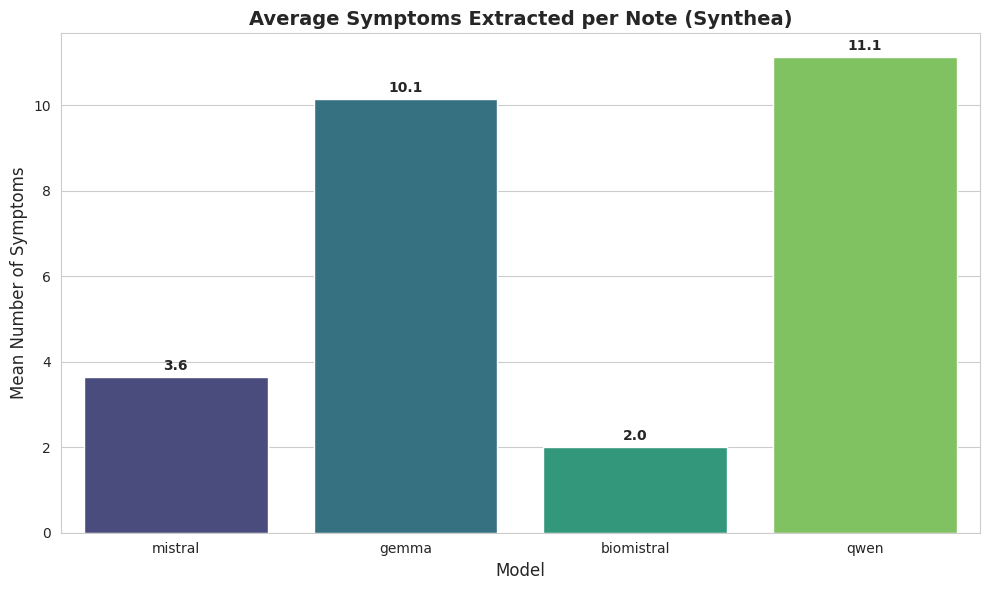

/tmp/ipykernel_55/305886359.py:188: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=diag_df, x='Model', y='Empty %', palette='Reds_r')


✓ Saved: synthea_viz_02_empty_predictions.png


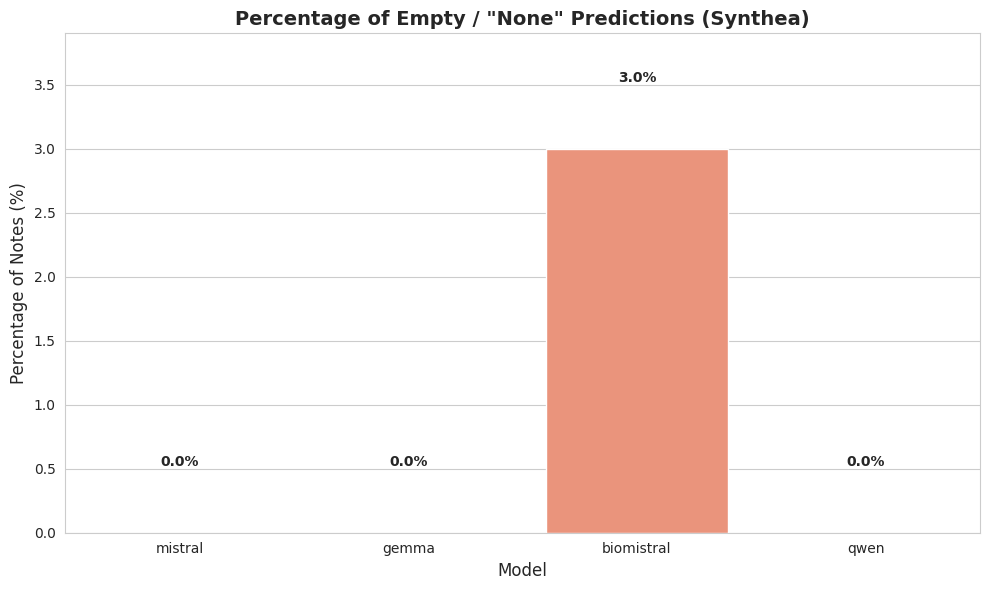

/tmp/ipykernel_55/305886359.py:207: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=diag_df, x='Model', y='Leakage %', palette=colors)


✓ Saved: synthea_viz_03_instruction_leakage.png


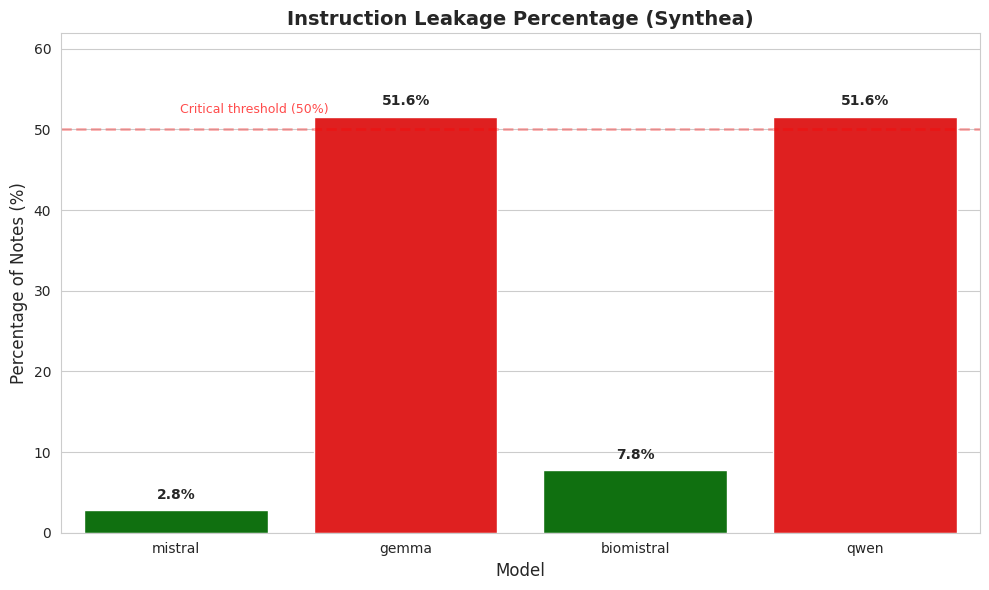


✓ Saved leakage details: 569 leaked notes
  See: synthea_leakage_details.csv

✓ Diagnostic visualizations complete


In [9]:
# CELL 8: Diagnostic Visualizations (viz_01, viz_02, viz_03) - FIXED
# ====================================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Creating diagnostic visualizations...")

# ============================================================================
# COMPREHENSIVE INSTRUCTION LEAKAGE DETECTION
# ============================================================================

def has_instruction_leakage(symptom_list):
    """
    Detect instruction leakage comprehensively.
    Checks for ANY fragment from the prompt template.
    """
    if not isinstance(symptom_list, list):
        return False
    
    # Convert all symptoms to lowercase string
    text = ' '.join(str(s).lower() for s in symptom_list)
    
    # INSTRUCTION KEYWORDS (from BASE_INSTRUCTION)
    instruction_keywords = [
        # Task description
        'clinical information extraction',
        'extract only',
        'patient-reported symptoms',
        'clinician-observed findings',
        'from the clinical note',
        
        # Rules section
        'task:',
        'rules:',
        'extract only symptoms',
        'clinical findings',
        'do not extract',
        'diagnoses',
        'medications',
        'labs',
        'procedures',
        'demographics',
        'family history',
        'negated symptoms',
        'denies chest pain',
        'do not include',
        'do not infer',
        'not explicitly mentioned',
        
        # Output format
        'output format',
        'one symptom per line',
        'starting with a hyphen',
        'starting with',
        'if no symptoms found',
        'output exactly',
        
        # Prompt structure
        'clinical note:',
        'extracted symptoms:',
        
        # Chat template artifacts
        '[inst]',
        '[/inst]',
        '<start_of_turn>',
        '<end_of_turn>',
        'user',
        'model',
        'assistant',
        
        # Generic instruction language
        'you are a',
        'your task is',
        'please extract',
        'based on the',
        'according to',
        'following rules',
        'use only',
        'make sure',
    ]
    
    # Check for any instruction keyword
    for keyword in instruction_keywords:
        if keyword in text:
            return True
    
    # ADDITIONAL CHECKS
    
    # Check for suspiciously long "symptoms" (likely instruction fragments)
    for symptom in symptom_list:
        symptom_str = str(symptom)
        # If any single symptom is > 100 chars, likely leakage
        if len(symptom_str) > 100:
            return True
        # If symptom contains multiple sentences, likely leakage
        if symptom_str.count('.') > 2:
            return True
    
    # Check for numbered/bulleted format instructions
    format_indicators = [
        'hyphen (-)',
        'bullet point',
        'numbered list',
        'format:',
    ]
    for indicator in format_indicators:
        if indicator in text:
            return True
    
    return False

# ============================================================================
# Calculate stats for each model
# ============================================================================

diagnostic_stats = []

for model_name, pred_df in all_predictions.items():
    # Merge to ensure we only count notes we evaluated
    merged = pred_df.merge(gold_df, on='note_id', how='inner')
    
    # Average symptoms
    avg_symptoms = merged['predictions'].apply(len).mean()
    
    # Empty predictions
    empty_count = merged['predictions'].apply(
        lambda x: len(x) == 0 or (len(x) == 1 and str(x[0]).lower() == 'none')
    ).sum()
    empty_pct = (empty_count / len(merged)) * 100
    
    # Instruction leakage detection (COMPREHENSIVE)
    leakage_count = merged['predictions'].apply(has_instruction_leakage).sum()
    leakage_pct = (leakage_count / len(merged)) * 100
    
    diagnostic_stats.append({
        'Model': model_name,
        'Avg Symptoms': avg_symptoms,
        'Empty Count': empty_count,
        'Empty %': empty_pct,
        'Leakage Count': leakage_count,
        'Leakage %': leakage_pct
    })
    
    # Print sample leaked predictions for debugging
    if leakage_count > 0:
        print(f"\n{model_name.upper()} - Sample leaked predictions:")
        leaked_samples = merged[merged['predictions'].apply(has_instruction_leakage)].head(3)
        for idx, row in leaked_samples.iterrows():
            print(f"  Note {row['note_id']}:")
            for i, symp in enumerate(row['predictions'][:5], 1):
                print(f"    {i}. {str(symp)[:100]}...")
            if len(row['predictions']) > 5:
                print(f"    ... and {len(row['predictions']) - 5} more")

diag_df = pd.DataFrame(diagnostic_stats)

print("\n" + "="*70)
print("DIAGNOSTIC STATISTICS")
print("="*70)
print(diag_df.to_string(index=False))

# ============================================================================
# VIZ 01: Average Symptoms
# ============================================================================

plt.figure(figsize=(10, 6))
sns.barplot(data=diag_df, x='Model', y='Avg Symptoms', palette='viridis')
plt.title('Average Symptoms Extracted per Note (Synthea)', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Mean Number of Symptoms', fontsize=12)
for i, row in diag_df.iterrows():
    plt.text(i, row['Avg Symptoms'] + 0.1, f"{row['Avg Symptoms']:.1f}", 
             ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/synthea_viz_01_avg_symptoms.png', dpi=300)
print("✓ Saved: synthea_viz_01_avg_symptoms.png")
plt.show()

# ============================================================================
# VIZ 02: Empty Predictions
# ============================================================================

plt.figure(figsize=(10, 6))
sns.barplot(data=diag_df, x='Model', y='Empty %', palette='Reds_r')
plt.title('Percentage of Empty / "None" Predictions (Synthea)', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Percentage of Notes (%)', fontsize=12)
plt.ylim(0, max(diag_df['Empty %']) * 1.3 if diag_df['Empty %'].max() > 0 else 10)
for i, row in diag_df.iterrows():
    plt.text(i, row['Empty %'] + 0.5, f"{row['Empty %']:.1f}%", 
             ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/synthea_viz_02_empty_predictions.png', dpi=300)
print("✓ Saved: synthea_viz_02_empty_predictions.png")
plt.show()

# ============================================================================
# VIZ 03: Instruction Leakage
# ============================================================================

plt.figure(figsize=(10, 6))
colors = ['red' if x > 50 else 'orange' if x > 10 else 'green' for x in diag_df['Leakage %']]
sns.barplot(data=diag_df, x='Model', y='Leakage %', palette=colors)
plt.title('Instruction Leakage Percentage (Synthea)', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Percentage of Notes (%)', fontsize=12)
plt.ylim(0, max(diag_df['Leakage %']) * 1.2 if diag_df['Leakage %'].max() > 0 else 10)
for i, row in diag_df.iterrows():
    plt.text(i, row['Leakage %'] + 1, f"{row['Leakage %']:.1f}%", 
             ha='center', va='bottom', fontweight='bold')

# Add warning annotation if high leakage
max_leakage = diag_df['Leakage %'].max()
if max_leakage > 50:
    plt.axhline(y=50, color='red', linestyle='--', alpha=0.3, linewidth=2)
    plt.text(0.02, 52, 'Critical threshold (50%)', fontsize=9, color='red', alpha=0.7)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/synthea_viz_03_instruction_leakage.png', dpi=300)
print("✓ Saved: synthea_viz_03_instruction_leakage.png")
plt.show()

# ============================================================================
# Save leakage details for inspection
# ============================================================================

if diag_df['Leakage Count'].sum() > 0:
    leakage_details = []
    
    for model_name, pred_df in all_predictions.items():
        merged = pred_df.merge(gold_df, on='note_id', how='inner')
        leaked_notes = merged[merged['predictions'].apply(has_instruction_leakage)]
        
        for _, row in leaked_notes.iterrows():
            leakage_details.append({
                'model': model_name,
                'note_id': row['note_id'],
                'prediction_sample': str(row['predictions'][:3])[:200],
                'num_predictions': len(row['predictions'])
            })
    
    if leakage_details:
        leakage_df = pd.DataFrame(leakage_details)
        leakage_df.to_csv(f'{OUTPUT_DIR}/synthea_leakage_details.csv', index=False)
        print(f"\n✓ Saved leakage details: {len(leakage_details)} leaked notes")
        print("  See: synthea_leakage_details.csv")

print("\n✓ Diagnostic visualizations complete")


Creating performance visualizations...


/tmp/ipykernel_55/3890420909.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_summary, x='Model', y='F1', palette='viridis')


✓ Saved: synthea_viz_07_f1_scores.png ⭐ MAIN RESULT


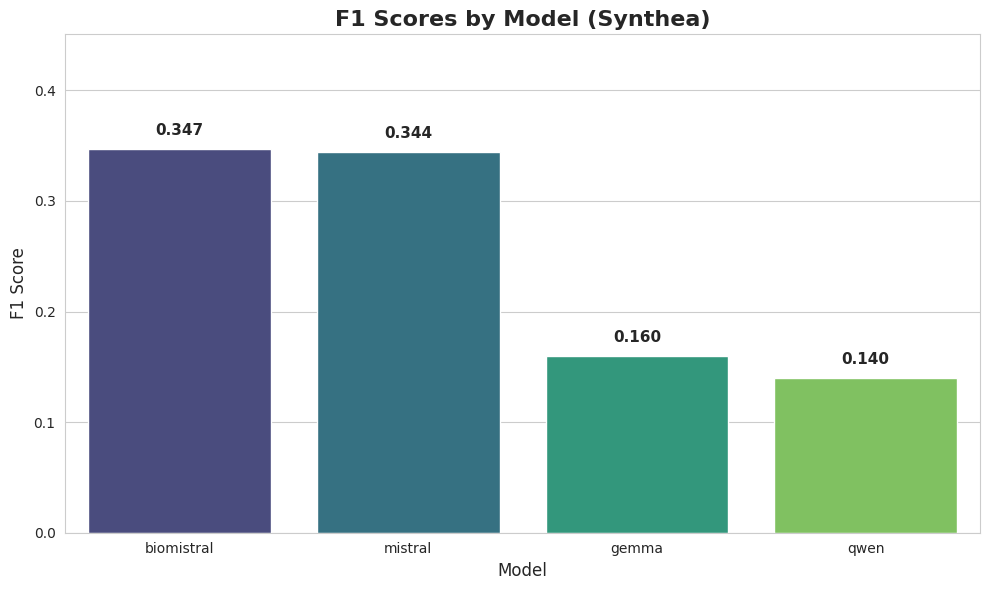

✓ Saved: synthea_viz_08_precision_recall_tradeoff.png


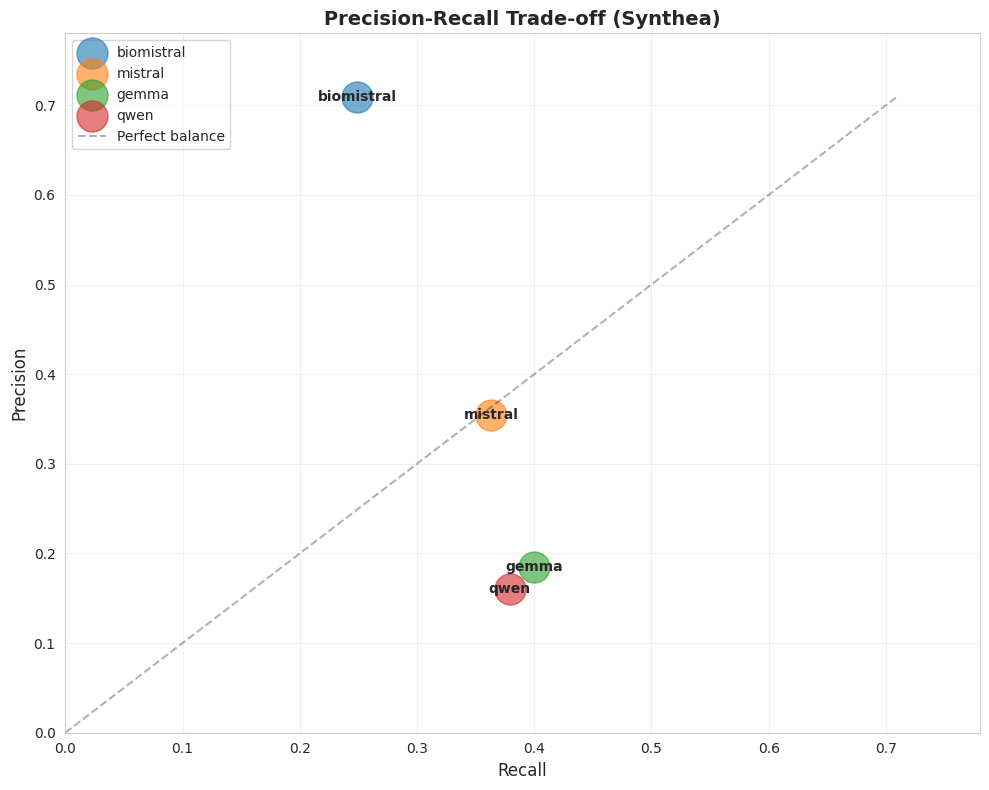

✓ Saved: synthea_viz_09_precision_recall_bars.png


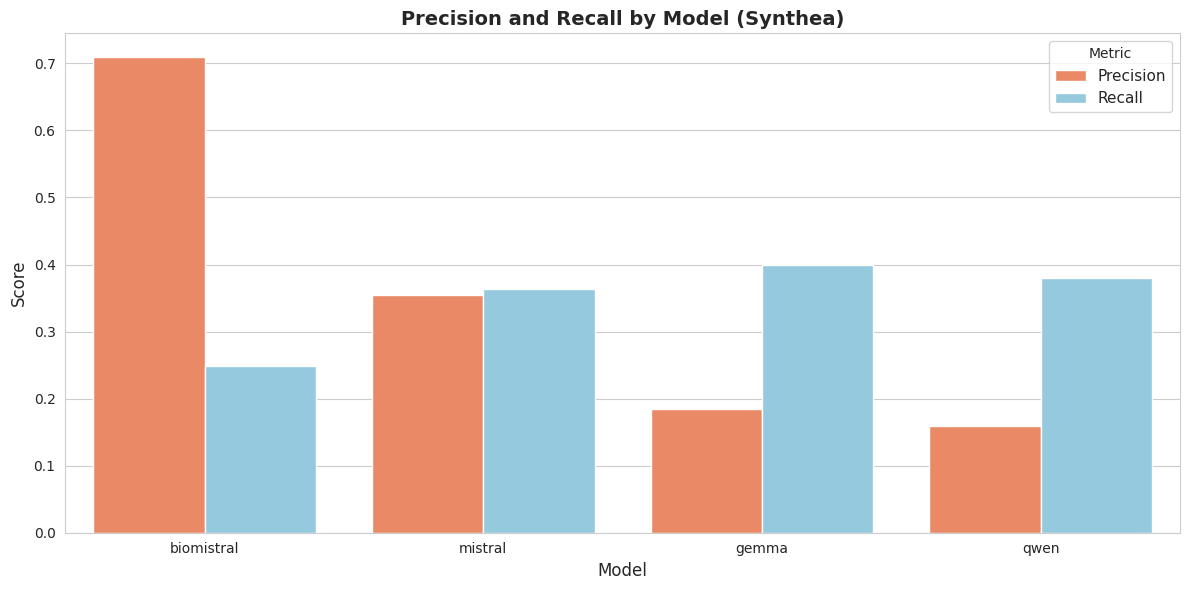

✓ Saved: synthea_viz_10_recall_vs_f1.png


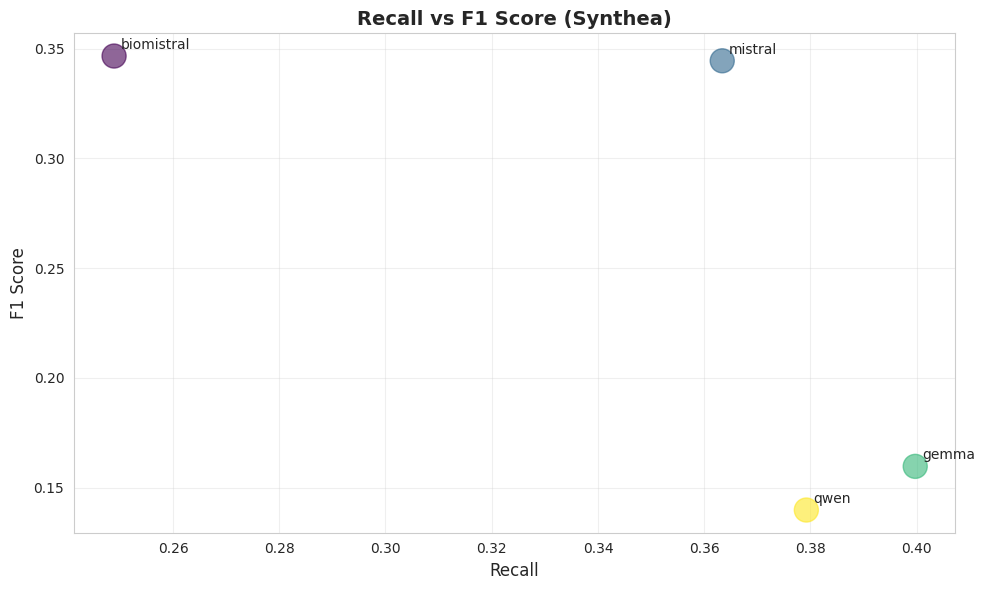

In [10]:
# CELL 9: Performance Visualizations (viz_07, viz_08, viz_09, viz_10)
# ====================================================================

print("\nCreating performance visualizations...")

# VIZ 07: F1 Scores (MAIN RESULT)
plt.figure(figsize=(10, 6))
plot_summary = summary_df.copy()
sns.barplot(data=plot_summary, x='Model', y='F1', palette='viridis')
plt.title('F1 Scores by Model (Synthea)', fontsize=16, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.ylim(0, max(plot_summary['F1']) * 1.3)

for i, row in plot_summary.iterrows():
    plt.text(i, row['F1'] + 0.01, f"{row['F1']:.3f}", 
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/synthea_viz_07_f1_scores.png', dpi=300)
print("✓ Saved: synthea_viz_07_f1_scores.png ⭐ MAIN RESULT")
plt.show()

# VIZ 08: Precision-Recall Trade-off
plt.figure(figsize=(10, 8))
for _, row in plot_summary.iterrows():
    plt.scatter(row['Recall'], row['Precision'], s=500, alpha=0.6, label=row['Model'])
    plt.annotate(row['Model'], (row['Recall'], row['Precision']), 
                ha='center', va='center', fontweight='bold', fontsize=10)

max_val = max(plot_summary['Precision'].max(), plot_summary['Recall'].max())
plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='Perfect balance')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Trade-off (Synthea)', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(0, max_val * 1.1)
plt.ylim(0, max_val * 1.1)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/synthea_viz_08_precision_recall_tradeoff.png', dpi=300)
print("✓ Saved: synthea_viz_08_precision_recall_tradeoff.png")
plt.show()

# VIZ 09: Precision & Recall Grouped Bars
plot_data = []
for _, row in plot_summary.iterrows():
    plot_data.append({'Model': row['Model'], 'Metric': 'Precision', 'Score': row['Precision']})
    plot_data.append({'Model': row['Model'], 'Metric': 'Recall', 'Score': row['Recall']})

plot_df = pd.DataFrame(plot_data)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric', palette=['coral', 'skyblue'])
plt.title('Precision and Recall by Model (Synthea)', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend(title='Metric', fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/synthea_viz_09_precision_recall_bars.png', dpi=300)
print("✓ Saved: synthea_viz_09_precision_recall_bars.png")
plt.show()

# VIZ 10: Recall vs F1
plt.figure(figsize=(10, 6))
plt.scatter(plot_summary['Recall'], plot_summary['F1'], s=300, alpha=0.6, 
           c=range(len(plot_summary)), cmap='viridis')

for _, row in plot_summary.iterrows():
    plt.annotate(row['Model'], (row['Recall'], row['F1']), 
                xytext=(5, 5), textcoords='offset points', fontsize=10)

plt.xlabel('Recall', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title('Recall vs F1 Score (Synthea)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/synthea_viz_10_recall_vs_f1.png', dpi=300)
print("✓ Saved: synthea_viz_10_recall_vs_f1.png")
plt.show()

In [11]:
# CELL 10: Extract Error Data for Analysis
# ====================================================================

print("\nExtracting error data...")

all_errors = []

for model_name, per_note_df in per_note_results.items():
    # Merge with predictions and gold
    pred_df = all_predictions[model_name]
    merged = per_note_df.merge(pred_df, on='note_id', how='inner')
    merged = merged.merge(gold_df, on='note_id', how='inner')
    
    for _, row in merged.iterrows():
        preds_norm = set(normalize(p) for p in row['predictions'] if p != 'none')
        preds_norm = {p for p in preds_norm if p}
        
        golds_norm = set(normalize(g) for g in row['gold'])
        golds_norm = {g for g in golds_norm if g}
        
        # Find false positives
        for pred in preds_norm:
            matched = any(pred in gold or gold in pred for gold in golds_norm)
            if not matched:
                all_errors.append({
                    'model': model_name,
                    'note_id': row['note_id'],
                    'error_type': 'false_positive',
                    'text': pred
                })
        
        # Find false negatives
        for gold in golds_norm:
            matched = any(pred in gold or gold in pred for pred in preds_norm)
            if not matched:
                all_errors.append({
                    'model': model_name,
                    'note_id': row['note_id'],
                    'error_type': 'false_negative',
                    'text': gold
                })

errors_df = pd.DataFrame(all_errors)
print(f"✓ Extracted {len(errors_df):,} total errors")

# Save error data
errors_df.to_csv(f'{OUTPUT_DIR}/synthea_error_data.csv', index=False)
print("✓ Saved: synthea_error_data.csv")


Extracting error data...
✓ Extracted 16,130 total errors
✓ Saved: synthea_error_data.csv



Creating error visualizations...
✓ Saved: synthea_viz_11_error_type_distribution.png


<Figure size 1200x600 with 0 Axes>

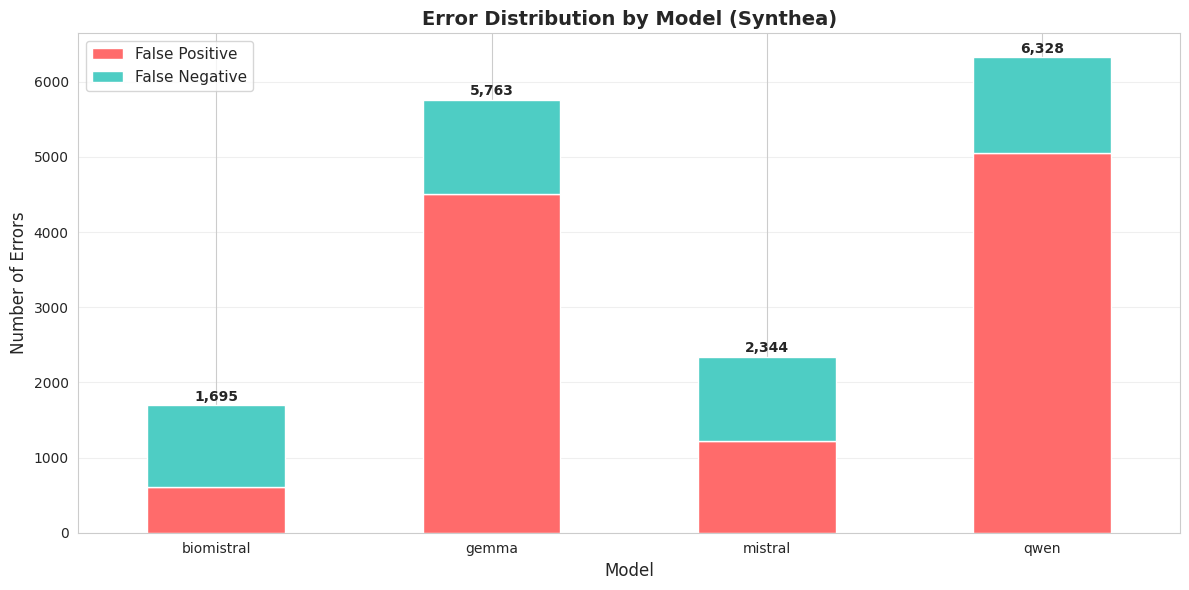


Error Summary:
error_type  false_negative  false_positive  total
model                                            
biomistral            1083             612   1695
gemma                 1253            4510   5763
mistral               1123            1221   2344
qwen                  1278            5050   6328


In [12]:
# CELL 11: Error Visualizations (viz_11)
# ====================================================================

print("\nCreating error visualizations...")

# Calculate error summaries
error_summary = errors_df.groupby(['model', 'error_type']).size().reset_index(name='count')
error_pivot = error_summary.pivot(index='model', columns='error_type', values='count').fillna(0)
error_pivot['total'] = error_pivot['false_positive'] + error_pivot['false_negative']

# VIZ 11: Error Type Distribution (Stacked Bar)
plt.figure(figsize=(12, 6))
error_pivot[['false_positive', 'false_negative']].plot(
    kind='bar', 
    stacked=True, 
    color=['#ff6b6b', '#4ecdc4'],
    figsize=(12, 6)
)
plt.title('Error Distribution by Model (Synthea)', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Number of Errors', fontsize=12)
plt.legend(['False Positive', 'False Negative'], 
          fontsize=11, loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Add total labels
for i, (idx, row) in enumerate(error_pivot.iterrows()):
    plt.text(i, row['total'] + 20, f"{int(row['total']):,}", 
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/synthea_viz_11_error_type_distribution.png', dpi=300)
print("✓ Saved: synthea_viz_11_error_type_distribution.png")
plt.show()

# Print error summary
print("\nError Summary:")
print(error_pivot.to_string())


Creating symptom distribution visualizations...
✓ Saved: synthea_viz_symptom_count_distribution.png


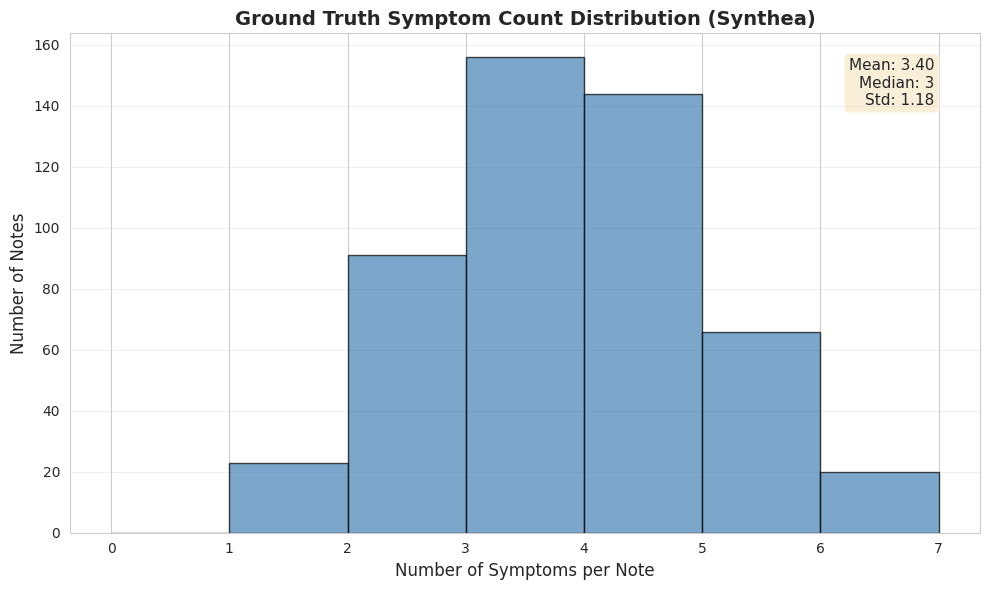

✓ Saved: synthea_viz_symptom_distribution_comparison.png


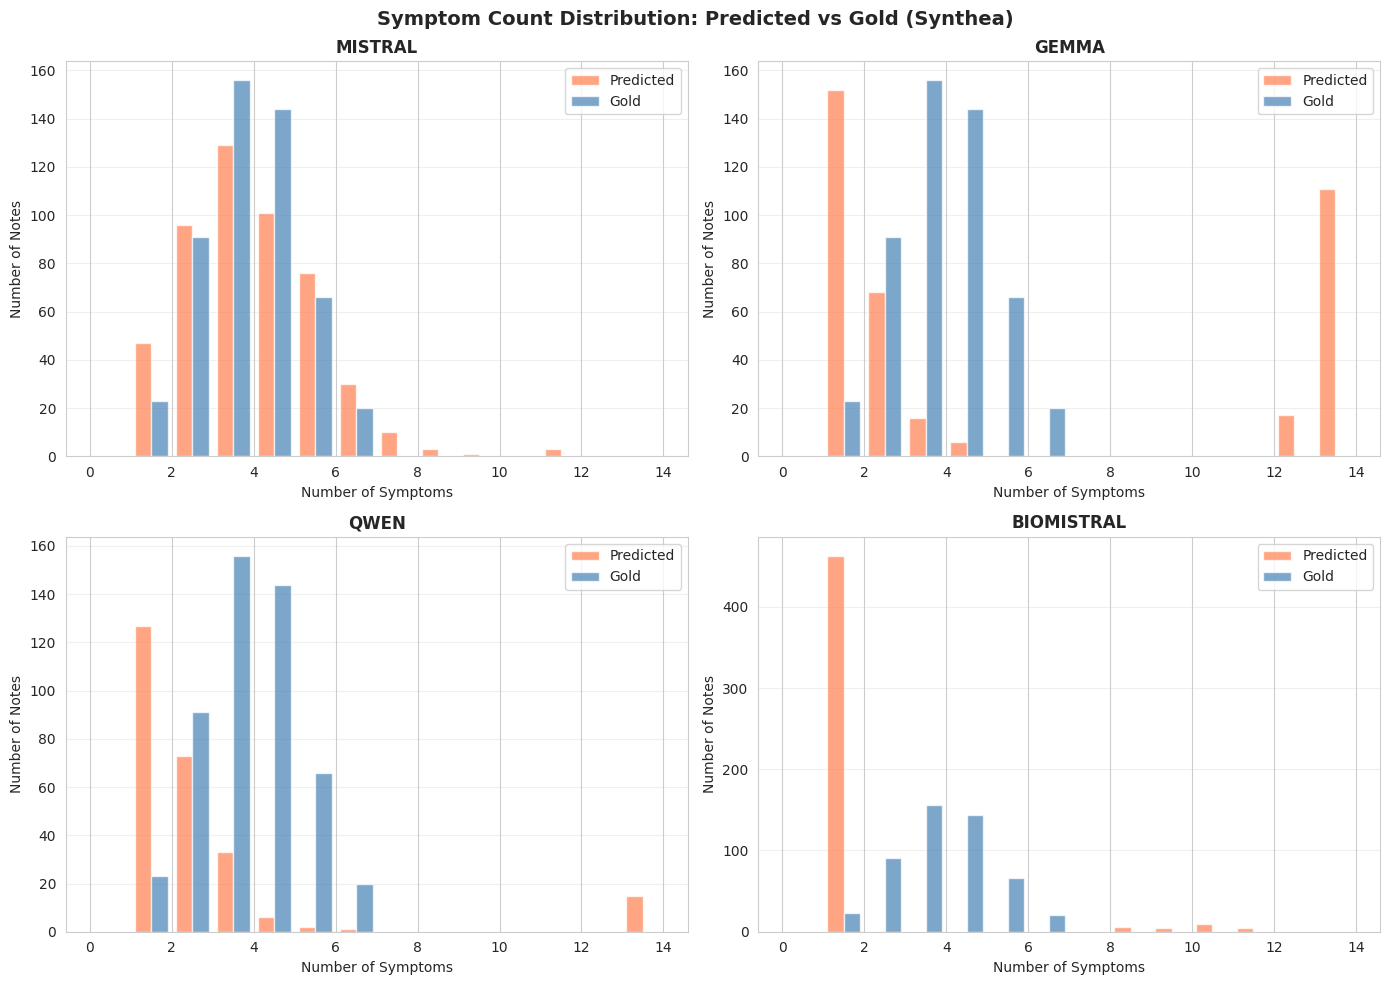

In [13]:
# CELL 12: Symptom Distribution Visualizations
# ====================================================================

print("\nCreating symptom distribution visualizations...")

# Symptom count distribution from gold standard
gold_symptom_counts = gold_df['gold'].apply(len)

plt.figure(figsize=(10, 6))
plt.hist(gold_symptom_counts, bins=range(0, gold_symptom_counts.max() + 2), 
         edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Number of Symptoms per Note', fontsize=12)
plt.ylabel('Number of Notes', fontsize=12)
plt.title('Ground Truth Symptom Count Distribution (Synthea)', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add statistics text
stats_text = f'Mean: {gold_symptom_counts.mean():.2f}\nMedian: {gold_symptom_counts.median():.0f}\nStd: {gold_symptom_counts.std():.2f}'
plt.text(0.95, 0.95, stats_text, transform=plt.gca().transAxes,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
         fontsize=11)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/synthea_viz_symptom_count_distribution.png', dpi=300)
print("✓ Saved: synthea_viz_symptom_count_distribution.png")
plt.show()

# Model comparison - symptom count distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, model_name in enumerate(['mistral', 'gemma', 'qwen', 'biomistral']):
    pred_df = all_predictions[model_name]
    merged = pred_df.merge(gold_df, on='note_id', how='inner')
    
    pred_counts = merged['predictions'].apply(len)
    gold_counts = merged['gold'].apply(len)
    
    axes[idx].hist([pred_counts, gold_counts], bins=range(0, 15), 
                   label=['Predicted', 'Gold'], alpha=0.7, color=['coral', 'steelblue'])
    axes[idx].set_title(f'{model_name.upper()}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Number of Symptoms', fontsize=10)
    axes[idx].set_ylabel('Number of Notes', fontsize=10)
    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Symptom Count Distribution: Predicted vs Gold (Synthea)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/synthea_viz_symptom_distribution_comparison.png', dpi=300)
print("✓ Saved: synthea_viz_symptom_distribution_comparison.png")
plt.show()


Creating cross-dataset comparison...
✓ Saved: synthea_viz_nbme_comparison.png


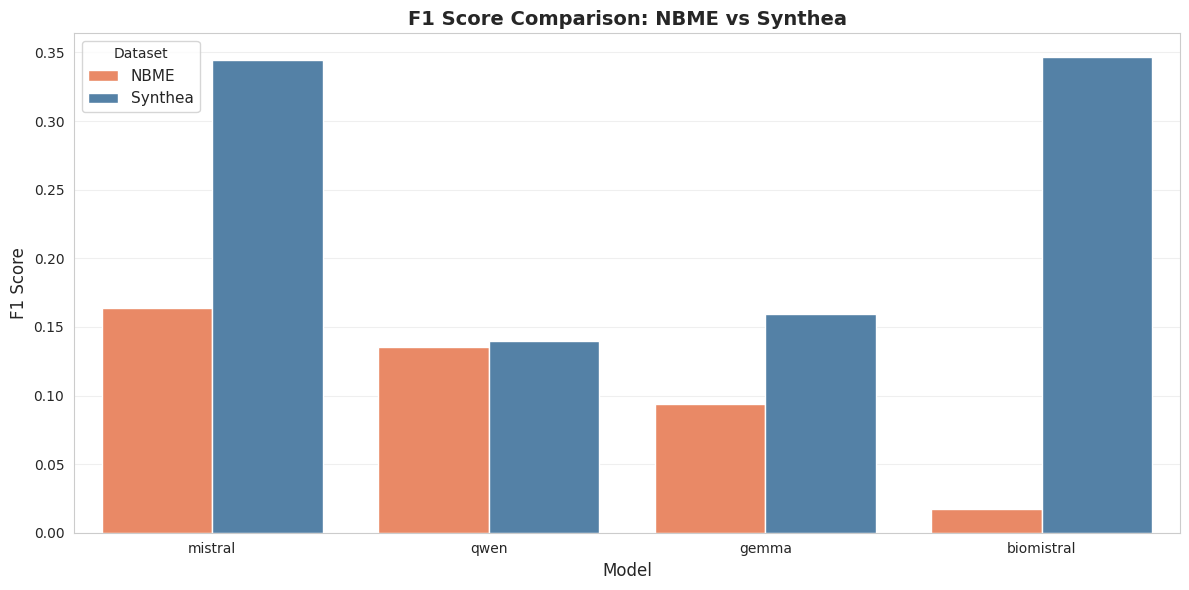


Cross-Dataset Performance:
     Model  NBME  Synthea  Improvement  Improvement %
biomistral 0.017 0.346611     0.329611         1938.9
     gemma 0.094 0.159693     0.065693           69.9
   mistral 0.164 0.344440     0.180440          110.0
      qwen 0.135 0.139809     0.004809            3.6
✓ Saved: synthea_nbme_comparison.csv


In [14]:
# CELL 13: Cross-Dataset Comparison Visualization
# ====================================================================

print("\nCreating cross-dataset comparison...")

# NBME results (from Member A) - update these with actual values
nbme_results = {
      'mistral': {'F1': 0.164, 'Precision': 0.182, 'Recall': 0.163},  # FROM YOUR NBME RESULTS
      'qwen': {'F1': 0.135, 'Precision': 0.155, 'Recall': 0.129},
      'gemma': {'F1': 0.094, 'Precision': 0.081, 'Recall': 0.123},
      'biomistral': {'F1': 0.017, 'Precision': 0.055, 'Recall': 0.011}
  }

# Create comparison data
comparison_data = []
for model in ['mistral', 'qwen', 'gemma', 'biomistral']:
    synthea_row = summary_df[summary_df['Model'] == model].iloc[0]
    
    comparison_data.append({
        'Model': model,
        'Dataset': 'NBME',
        'F1': nbme_results[model]['F1']
    })
    comparison_data.append({
        'Model': model,
        'Dataset': 'Synthea',
        'F1': synthea_row['F1']
    })

comparison_df = pd.DataFrame(comparison_data)

# Plot comparison
plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_df, x='Model', y='F1', hue='Dataset', palette=['coral', 'steelblue'])
plt.title('F1 Score Comparison: NBME vs Synthea', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.legend(title='Dataset', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/synthea_viz_nbme_comparison.png', dpi=300)
print("✓ Saved: synthea_viz_nbme_comparison.png")
plt.show()

# Save comparison data
comparison_df_wide = comparison_df.pivot(index='Model', columns='Dataset', values='F1').reset_index()
comparison_df_wide['Improvement'] = comparison_df_wide['Synthea'] - comparison_df_wide['NBME']
comparison_df_wide['Improvement %'] = (comparison_df_wide['Improvement'] / comparison_df_wide['NBME'] * 100).round(1)

print("\nCross-Dataset Performance:")
print(comparison_df_wide.to_string(index=False))

comparison_df_wide.to_csv(f'{OUTPUT_DIR}/synthea_nbme_comparison.csv', index=False)
print("✓ Saved: synthea_nbme_comparison.csv")

In [15]:
# CELL 14: Create Summary Statistics Table
# ====================================================================

print("\nCreating comprehensive summary table...")

# Combine all statistics
summary_table = summary_df.copy()

# Add diagnostic stats
summary_table = summary_table.merge(
    diag_df[['Model', 'Avg Symptoms', 'Empty %', 'Leakage %']], 
    on='Model'
)

# Format for display
summary_table_formatted = summary_table.copy()
summary_table_formatted['Precision'] = summary_table_formatted['Precision'].apply(lambda x: f"{x:.3f}")
summary_table_formatted['Recall'] = summary_table_formatted['Recall'].apply(lambda x: f"{x:.3f}")
summary_table_formatted['F1'] = summary_table_formatted['F1'].apply(lambda x: f"{x:.3f}")
summary_table_formatted['Avg Symptoms'] = summary_table_formatted['Avg Symptoms'].apply(lambda x: f"{x:.1f}")
summary_table_formatted['Empty %'] = summary_table_formatted['Empty %'].apply(lambda x: f"{x:.1f}%")
summary_table_formatted['Leakage %'] = summary_table_formatted['Leakage %'].apply(lambda x: f"{x:.1f}%")

print("\nCOMPREHENSIVE SYNTHEA RESULTS:")
print("="*100)
print(summary_table_formatted.to_string(index=False))
print("="*100)

# Save
summary_table.to_csv(f'{OUTPUT_DIR}/synthea_comprehensive_summary.csv', index=False)
print("\n✓ Saved: synthea_comprehensive_summary.csv")


Creating comprehensive summary table...

COMPREHENSIVE SYNTHEA RESULTS:
     Model Precision Recall    F1  TP   FP   FN Avg Symptoms Empty % Leakage %
biomistral     0.709  0.249 0.347 375  612 1324          2.0    3.0%      7.8%
   mistral     0.355  0.363 0.344 597 1221 1102          3.6    0.0%      2.8%
     gemma     0.184  0.400 0.160 561 4510 1138         10.1    0.0%     51.6%
      qwen     0.160  0.379 0.140 511 5050 1188         11.1    0.0%     51.6%

✓ Saved: synthea_comprehensive_summary.csv


POST-PROCESSING ANALYSIS

Post-processing MISTRAL...
  Raw mean: 3.64 → Post mean: 3.47
  Raw empty: 0 → Post empty: 1
  Total items removed: 85

  Sample removed items (first note with removals):
    From note eaf52c8f-0da7-481a-bf26-5ea13dba9137:
      ✗ 'n'

Post-processing GEMMA...
  Raw mean: 10.14 → Post mean: 6.27
  Raw empty: 0 → Post empty: 11
  Total items removed: 1935

  Sample removed items (first note with removals):
    From note eaf52c8f-0da7-481a-bf26-5ea13dba9137:
      ✗ 'do not include negated symptoms (e.g., "denies chest pain")'
      ✗ 'if no symptoms found, output exactly: none'
      ✗ 'extract only symptoms and clinical findings'

Post-processing BIOMISTRAL...
  Raw mean: 2.00 → Post mean: 1.48
  Raw empty: 15 → Post empty: 16
  Total items removed: 264

  Sample removed items (first note with removals):
    From note f2daeda0-ae6d-403f-8389-e507e33bbdeb:
      ✗ 'do not include negated symptoms (e.g., "denies chest pain")'
      ✗ 'extract only symptoms and c

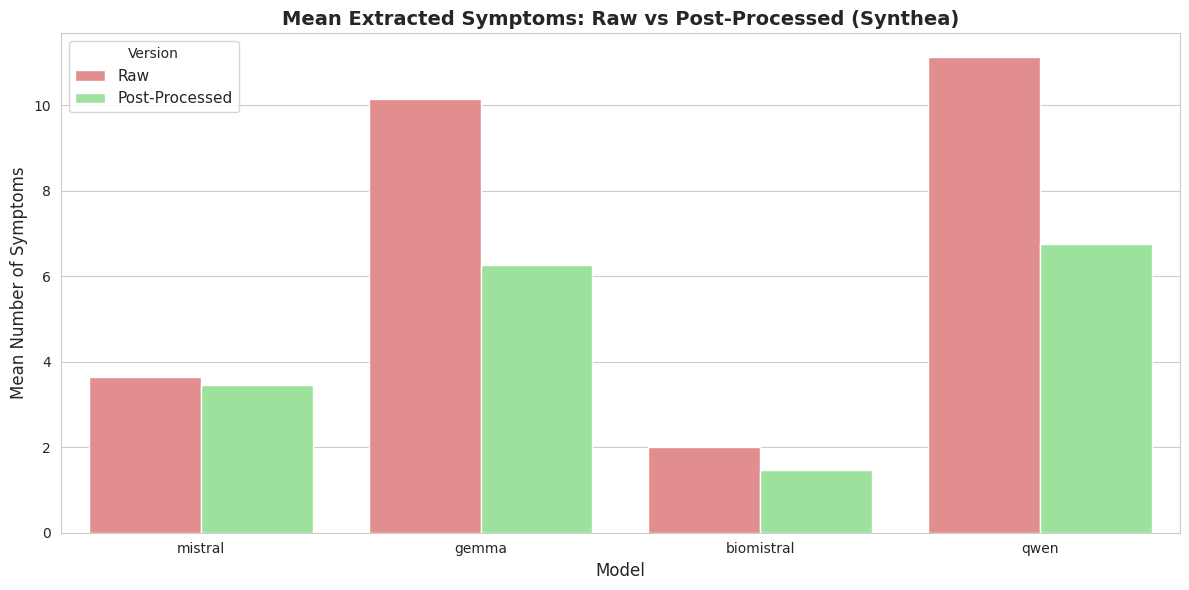

✓ Saved: synthea_viz_06_before_after_empty.png


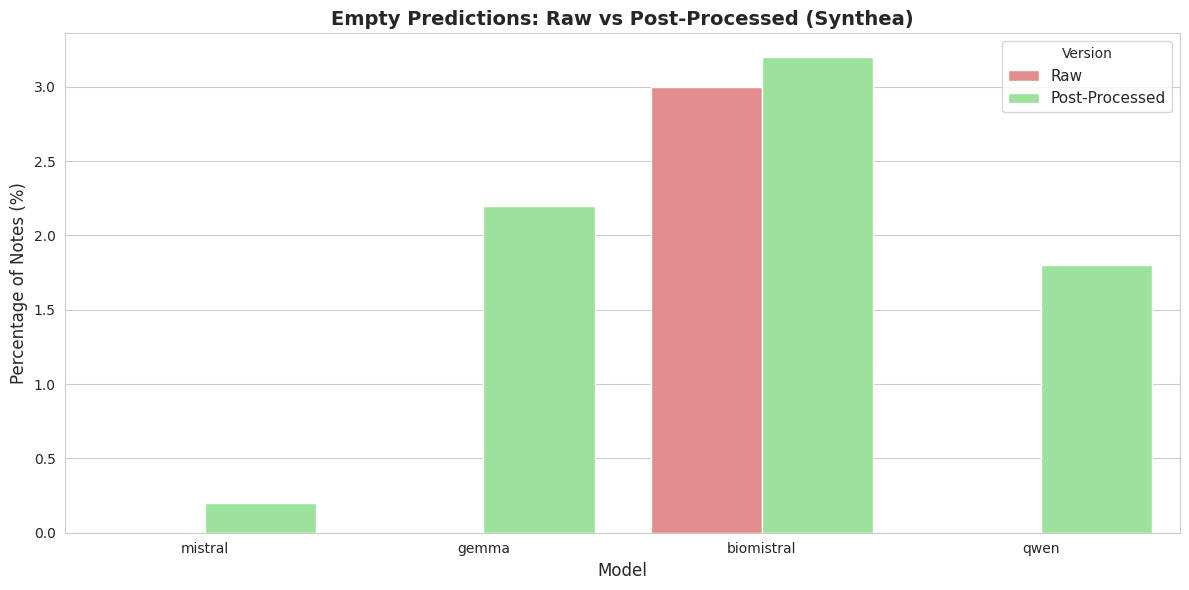


✅ Post-processing complete with comprehensive instruction filtering


In [16]:
# CELL 15: Post-Processing Analysis (COMPREHENSIVE)
# ====================================================================

print("="*70)
print("POST-PROCESSING ANALYSIS")
print("="*70)

# ============================================================================
# COMPREHENSIVE INSTRUCTION FRAGMENT LIST
# ============================================================================

# Based on the actual BASE_INSTRUCTION used in inference
INSTRUCTION_FRAGMENTS = [
    # From "You are a clinical information extraction system"
    'you are a',
    'clinical information extraction',
    'information extraction',
    'extraction system',
    
    # From "TASK:" section
    'task:',
    'extract only',
    'patient-reported symptoms',
    'patient reported symptoms',
    'clinician-observed findings',
    'clinician observed findings',
    'from the clinical note',
    'clinical note',
    
    # From "RULES:" section
    'rules:',
    'extract only symptoms',
    'clinical findings',
    'do not extract',
    'diagnoses',
    'medications',
    'labs',
    'procedures',
    'demographics',
    'family history',
    'do not include',
    'negated symptoms',
    'denies chest pain',  # Example from prompt
    'do not infer',
    'not explicitly mentioned',
    'explicitly mentioned',
    
    # From "Output format:" section
    'output format',
    'one symptom per line',
    'symptom per line',
    'starting with a hyphen',
    'starting with',
    'each starting with',
    'hyphen (-)',
    'if no symptoms found',
    'no symptoms found',
    'output exactly',
    'exactly:',
    
    # From prompt structure markers
    'clinical note:',
    'extracted symptoms:',
    'symptoms:',
    
    # Chat template artifacts (Mistral)
    '[inst]',
    '[/inst]',
    'inst]',
    
    # Chat template artifacts (Gemma)
    '<start_of_turn>',
    '<end_of_turn>',
    'start_of_turn',
    'end_of_turn',
    
    # Chat template artifacts (Qwen)
    '<|im_start|>',
    '<|im_end|>',
    'im_start',
    'im_end',
    
    # Role indicators from chat templates
    'user:',
    'assistant:',
    'model:',
    'system:',
    
    # Generic instruction language
    'you are',
    'your task',
    'please extract',
    'based on the',
    'according to',
    'following rules',
    'use only',
    'make sure',
    'remember to',
    'be sure to',
    
    # Meta-commentary that indicates instruction leakage
    'as instructed',
    'as requested',
    'here are the',
    'here is the',
    'the following',
    'listed below',
    'below are',
    
    # Common prefix artifacts
    'note:',
    'response:',
    'answer:',
    'output:',
    
    # Formatting artifacts
    'bullet point',
    'numbered list',
    'list format',
]

def postprocess_predictions(raw_predictions):
    """
    Clean predictions following Member A's methodology.
    Now with comprehensive instruction fragment detection.
    """
    if not isinstance(raw_predictions, list):
        return []
    
    symptoms = []
    
    for symptom in raw_predictions:
        if not isinstance(symptom, str):
            continue
        
        # Skip if it's 'none'
        if symptom.lower().strip() == 'none':
            continue
        
        # Normalize
        cleaned = symptom.lower().strip()
        
        # Remove quotes and extra punctuation
        cleaned = cleaned.strip('"\'".,;:')
        
        # Skip empty
        if not cleaned or len(cleaned) < 2:
            continue
        
        # ========================================
        # COMPREHENSIVE INSTRUCTION DETECTION
        # ========================================
        
        # Check for instruction fragments
        is_instruction = False
        for fragment in INSTRUCTION_FRAGMENTS:
            if fragment in cleaned:
                # But allow if it's a legitimate medical term that happens to contain the fragment
                # E.g., "chest pain based on examination" should be caught
                # but "pain" should not be caught by "pain" fragment
                
                # If the fragment is a substantial part of the cleaned text, it's likely instruction
                if len(fragment) > 5 and len(fragment) / len(cleaned) > 0.3:
                    is_instruction = True
                    break
                # Or if the fragment appears at the start/end (typical instruction position)
                elif cleaned.startswith(fragment) or cleaned.endswith(fragment):
                    is_instruction = True
                    break
                # Or if it's a known instruction marker
                elif fragment in ['task:', 'rules:', 'output:', 'note:', 'extracted symptoms:']:
                    is_instruction = True
                    break
        
        if is_instruction:
            continue
        
        # ========================================
        # LENGTH-BASED FILTERING
        # ========================================
        
        # Skip suspiciously long "symptoms" (likely instruction fragments)
        if len(cleaned) > 100:
            continue
        
        # Skip if contains multiple sentences (multiple periods)
        if cleaned.count('.') > 2:
            continue
        
        # Skip if contains multiple colons (formatting indicator)
        if cleaned.count(':') > 1:
            continue
        
        # ========================================
        # STRUCTURAL FILTERING
        # ========================================
        
        # Skip if it's clearly a formatting instruction
        if any(marker in cleaned for marker in ['->', '=>', '•', '*', '1.', '2.', '3.']):
            # But allow if it's actually part of medical terminology
            if not any(medical in cleaned for medical in ['>', '<', 'less than', 'greater than']):
                continue
        
        # ========================================
        # ACCEPT THE SYMPTOM
        # ========================================
        
        symptoms.append(cleaned)
    
    # Remove duplicates while preserving order
    seen = set()
    unique_symptoms = []
    for s in symptoms:
        if s not in seen:
            seen.add(s)
            unique_symptoms.append(s)
    
    return unique_symptoms if unique_symptoms else ['none']

# ============================================================================
# Apply post-processing to all models
# ============================================================================

postprocessed_predictions = {}
comparison_stats = []

for model_name, pred_df in all_predictions.items():
    print(f"\nPost-processing {model_name.upper()}...")
    
    # Apply post-processing
    pred_df['predictions_postprocessed'] = pred_df['predictions'].apply(postprocess_predictions)
    
    # Calculate statistics
    raw_mean = pred_df['predictions'].apply(len).mean()
    post_mean = pred_df['predictions_postprocessed'].apply(len).mean()
    
    raw_empty = (pred_df['predictions'].apply(lambda x: len(x) == 0 or x == ['none'])).sum()
    post_empty = (pred_df['predictions_postprocessed'].apply(lambda x: x == ['none'])).sum()
    
    # Count how many items were removed
    total_removed = sum(
        len(raw) - len(post) 
        for raw, post in zip(pred_df['predictions'], pred_df['predictions_postprocessed'])
    )
    
    comparison_stats.append({
        'Model': model_name,
        'Raw Mean': raw_mean,
        'Post Mean': post_mean,
        'Mean Change': post_mean - raw_mean,
        'Raw Empty': raw_empty,
        'Post Empty': post_empty,
        'Empty Change': post_empty - raw_empty,
        'Items Removed': total_removed
    })
    
    # Save postprocessed predictions
    output_df = pred_df[['note_id', 'predictions_postprocessed']].copy()
    output_df.to_csv(f'{OUTPUT_DIR}/{model_name}_predictions_postprocessed.csv', index=False)
    
    # Also save the original as "cleaned"
    output_df_raw = pred_df[['note_id', 'predictions']].copy()
    output_df_raw.to_csv(f'{OUTPUT_DIR}/{model_name}_predictions_cleaned.csv', index=False)
    
    postprocessed_predictions[model_name] = pred_df
    
    print(f"  Raw mean: {raw_mean:.2f} → Post mean: {post_mean:.2f}")
    print(f"  Raw empty: {raw_empty} → Post empty: {post_empty}")
    print(f"  Total items removed: {total_removed}")
    
    # Show sample of what was removed
    if total_removed > 0:
        print(f"\n  Sample removed items (first note with removals):")
        for idx, (raw, post) in enumerate(zip(pred_df['predictions'], pred_df['predictions_postprocessed'])):
            removed = set(raw) - set(post)
            if removed:
                print(f"    From note {pred_df.iloc[idx]['note_id']}:")
                for item in list(removed)[:3]:
                    print(f"      ✗ '{item[:80]}'")
                break

comparison_df = pd.DataFrame(comparison_stats)

# Save comparison
comparison_df.to_csv(f'{OUTPUT_DIR}/synthea_postprocessing_comparison.csv', index=False)
print("\n✓ Saved: synthea_postprocessing_comparison.csv")

print("\n" + "="*70)
print("POST-PROCESSING SUMMARY")
print("="*70)
print(comparison_df.to_string(index=False))

# ============================================================================
# VIZ 05: Before/After Average Symptoms
# ============================================================================

plot_data = []
for _, row in comparison_df.iterrows():
    plot_data.append({'Model': row['Model'], 'Type': 'Raw', 'Mean Symptoms': row['Raw Mean']})
    plot_data.append({'Model': row['Model'], 'Type': 'Post-Processed', 'Mean Symptoms': row['Post Mean']})

plot_df = pd.DataFrame(plot_data)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='Model', y='Mean Symptoms', hue='Type', palette=['lightcoral', 'lightgreen'])
plt.title('Mean Extracted Symptoms: Raw vs Post-Processed (Synthea)', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Mean Number of Symptoms', fontsize=12)
plt.legend(title='Version', fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/synthea_viz_05_before_after_symptoms.png', dpi=300)
print("✓ Saved: synthea_viz_05_before_after_symptoms.png")
plt.show()

# ============================================================================
# VIZ 06: Before/After Empty Predictions
# ============================================================================

plot_data_empty = []
total_notes = len(gold_df)
for _, row in comparison_df.iterrows():
    plot_data_empty.append({
        'Model': row['Model'], 
        'Type': 'Raw', 
        'Empty %': (row['Raw Empty'] / total_notes) * 100
    })
    plot_data_empty.append({
        'Model': row['Model'], 
        'Type': 'Post-Processed', 
        'Empty %': (row['Post Empty'] / total_notes) * 100
    })

plot_df_empty = pd.DataFrame(plot_data_empty)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df_empty, x='Model', y='Empty %', hue='Type', palette=['lightcoral', 'lightgreen'])
plt.title('Empty Predictions: Raw vs Post-Processed (Synthea)', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Percentage of Notes (%)', fontsize=12)
plt.legend(title='Version', fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/synthea_viz_06_before_after_empty.png', dpi=300)
print("✓ Saved: synthea_viz_06_before_after_empty.png")
plt.show()

print("\n✅ Post-processing complete with comprehensive instruction filtering")

In [17]:
# ====================================================================
# CELL 16 (REWRITTEN): NON-PARAMETRIC PAIRED COMPARISONS (SYNTHEA)
# ====================================================================
# Reviewer-safe replacement for paired t-tests
# Uses Wilcoxon signed-rank test + rank-biserial correlation
# ====================================================================

from scipy.stats import wilcoxon
import numpy as np
import pandas as pd

print("=" * 70)
print("NON-PARAMETRIC PAIRED MODEL COMPARISONS (SYNTHEA)")
print("=" * 70)

models = list(per_note_results.keys())
pairwise_results = []

for i in range(len(models)):
    for j in range(i + 1, len(models)):
        model1 = models[i]
        model2 = models[j]

        metrics1 = per_note_results[model1]
        metrics2 = per_note_results[model2]

        # Align per-note F1 scores
        merged = metrics1.merge(
            metrics2,
            on="note_id",
            suffixes=("_1", "_2")
        )

        diff = merged["f1_1"] - merged["f1_2"]

        # Skip degenerate comparisons
        if diff.nunique() <= 1:
            p_value = np.nan
            stat = np.nan
            rank_biserial = 0.0
            median_diff = diff.median()
        else:
            stat, p_value = wilcoxon(
                diff,
                zero_method="zsplit",
                alternative="two-sided"
            )

            # Rank-biserial correlation (paired, non-parametric effect size)
            rank_biserial = (
                np.sum(diff > 0) - np.sum(diff < 0)
            ) / len(diff)

            median_diff = diff.median()

        pairwise_results.append({
            "Comparison": f"{model1} vs {model2}",
            "Median F1 Difference": float(median_diff),
            "Wilcoxon Statistic": float(stat) if not np.isnan(stat) else np.nan,
            "p-value": float(p_value) if not np.isnan(p_value) else np.nan,
            "Rank-Biserial r": float(rank_biserial)
        })

pairwise_df = pd.DataFrame(pairwise_results)

# Bonferroni correction (reported conservatively)
n_comparisons = len(pairwise_df)
bonferroni_alpha = 0.05 / n_comparisons

pairwise_df["Bonferroni α"] = bonferroni_alpha
pairwise_df["Significant (Bonferroni)"] = (
    pairwise_df["p-value"] < bonferroni_alpha
)

print("\n", pairwise_df.to_string(index=False))

# Save results
pairwise_df.to_csv(
    f"{OUTPUT_DIR}/synthea_table3_nonparametric_tests.csv",
    index=False
)

print(f"\n✓ Saved: synthea_table3_nonparametric_tests.csv")
print(f"Bonferroni correction applied: α = {bonferroni_alpha:.4f}")

print("\nNOTE:")
print("These paired non-parametric tests assess relative model consistency")
print("across synthetic notes and are reported conservatively.")
print("=" * 70)

# ====================================================================
# CELL 16: STATISTICAL SIGNIFICANCE TESTS (WILCOXON)
# ====================================================================

from scipy.stats import wilcoxon
import numpy as np

print("="*70)
print("STATISTICAL SIGNIFICANCE TESTS (WILCOXON)")
print("="*70)

models = list(per_note_results.keys())
pairwise_results = []

for i in range(len(models)):
    for j in range(i+1, len(models)):
        model1 = models[i]
        model2 = models[j]
        
        metrics1 = per_note_results[model1]
        metrics2 = per_note_results[model2]
        
        merged = metrics1.merge(metrics2, on='note_id', suffixes=('_1', '_2'))
        
        # Wilcoxon signed-rank test
        try:
            stat, p_value = wilcoxon(merged['f1_1'], merged['f1_2'], zero_method='wilcox')
        except ValueError:
            stat, p_value = 0, 1.0
        
        # Paired Cohen's d
        diff = merged['f1_1'] - merged['f1_2']
        mean_diff = diff.mean()
        std_diff = diff.std()
        cohens_d = mean_diff / std_diff if std_diff > 0 else 0
        
        pairwise_results.append({
            'Comparison': f'{model1} vs {model2}',
            'Mean Diff': float(mean_diff),
            'Wilcoxon Statistic': float(stat),
            'p-value': float(p_value),
            "Cohen's d": float(cohens_d),
            'Significant (α=0.05)': 'Yes***' if p_value < 0.001 else 'Yes**' if p_value < 0.01 else 'Yes*' if p_value < 0.05 else 'No'
        })

pairwise_df = pd.DataFrame(pairwise_results)

# Bonferroni correction
n_comparisons = len(pairwise_df)
bonferroni_alpha = 0.05 / n_comparisons
pairwise_df['Significant (Bonferroni)'] = pairwise_df['p-value'] < bonferroni_alpha

print("\n", pairwise_df.to_string(index=False))
print(f"\nBonferroni correction: α = 0.05 / {n_comparisons} = {bonferroni_alpha:.4f}")

pairwise_df.to_csv(f'{OUTPUT_DIR}/synthea_table3_statistical_tests.csv', index=False)
print("✓ Saved: synthea_table3_statistical_tests.csv")

NON-PARAMETRIC PAIRED MODEL COMPARISONS (SYNTHEA)

            Comparison  Median F1 Difference  Wilcoxon Statistic      p-value  Rank-Biserial r  Bonferroni α  Significant (Bonferroni)
     mistral vs gemma              0.169048             22315.0 1.004680e-35            0.422      0.008333                      True
mistral vs biomistral              0.000000             60847.0 5.819598e-01            0.018      0.008333                     False
      mistral vs qwen              0.180195             15658.5 6.547438e-48            0.518      0.008333                      True
  gemma vs biomistral             -0.166667             21058.5 5.907159e-38           -0.480      0.008333                      True
        gemma vs qwen              0.000000             49305.5 3.602491e-05            0.232      0.008333                      True
   biomistral vs qwen              0.222876             15127.0 4.448418e-49            0.544      0.008333                      True

✓ Saved: 

BOOTSTRAP UNCERTAINTY INTERVALS (CORPUS-LEVEL METRICS)

      Model  Precision  Precision Lower  Precision Upper   Recall  Recall Lower  Recall Upper       F1  F1 Lower  F1 Upper
   mistral   0.328383         0.303269         0.353871 0.351383      0.326388      0.374936 0.339494  0.315928  0.363226
     gemma   0.110629         0.101454         0.119906 0.330194      0.299710      0.361541 0.165731  0.152403  0.177651
biomistral   0.379939         0.322371         0.455790 0.220718      0.208929      0.233353 0.279226  0.256555  0.303502
      qwen   0.091890         0.083799         0.099275 0.300765      0.269854      0.333738 0.140771  0.129081  0.151318

✓ Saved: synthea_table4_bootstrap_uncertainty.csv
✓ Saved: synthea_viz_17_f1_bootstrap_uncertainty.png


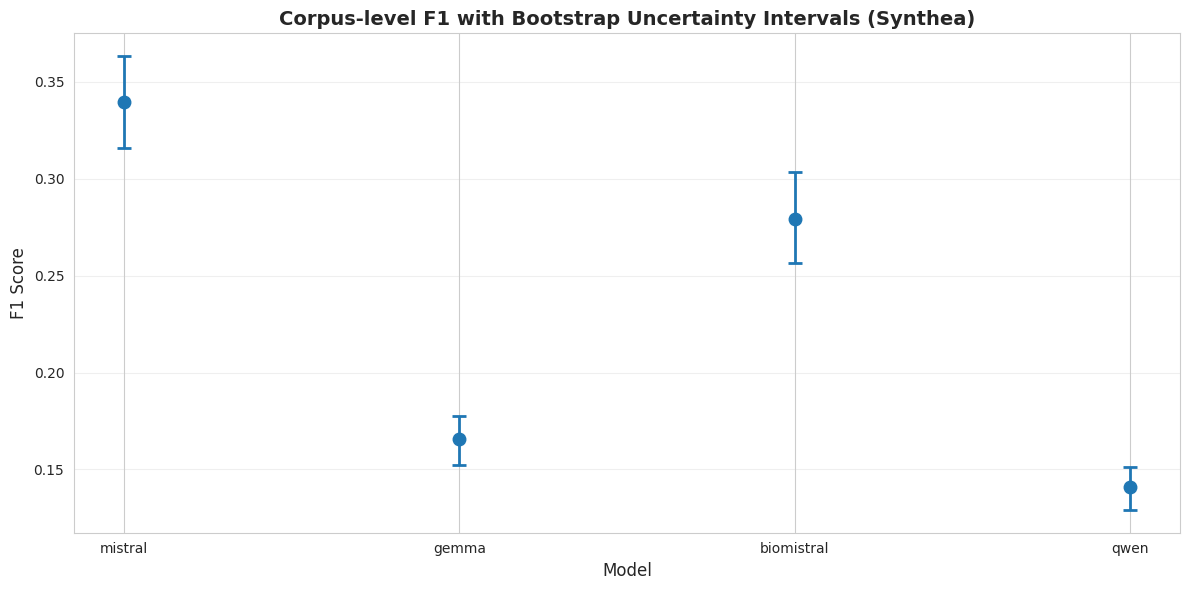

NOTE:
Bootstrap resamples notes and recomputes corpus-level metrics.
Intervals reflect metric uncertainty, not population inference.


In [18]:
# ====================================================================
# CELL 17 (REWRITTEN): BOOTSTRAP UNCERTAINTY INTERVALS (SYNTHEA)
# ====================================================================
# Reviewer-safe bootstrap:
# - Resamples NOTES
# - Recomputes CORPUS-LEVEL Precision / Recall / F1 each iteration
# - Bootstraps TP / FP / FN jointly
# - Reports uncertainty intervals (not population CIs)
# ====================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("BOOTSTRAP UNCERTAINTY INTERVALS (CORPUS-LEVEL METRICS)")
print("=" * 70)

N_BOOTSTRAP = 1000
CI = 0.95
ALPHA_LOW = (1 - CI) / 2 * 100
ALPHA_HIGH = (1 + CI) / 2 * 100

def bootstrap_corpus_metrics(per_note_df, n_bootstrap=N_BOOTSTRAP):
    """
    Bootstrap corpus-level metrics by resampling notes.
    per_note_df must contain columns: ['note_id', 'tp', 'fp', 'fn']
    """
    metrics = {
        "precision": [],
        "recall": [],
        "f1": []
    }

    note_ids = per_note_df["note_id"].values

    for _ in range(n_bootstrap):
        # Resample notes with replacement
        sampled_ids = np.random.choice(note_ids, size=len(note_ids), replace=True)
        sample = per_note_df.set_index("note_id").loc[sampled_ids].reset_index()

        TP = sample["tp"].sum()
        FP = sample["fp"].sum()
        FN = sample["fn"].sum()

        precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        f1 = (
            2 * precision * recall / (precision + recall)
            if (precision + recall) > 0
            else 0.0
        )

        metrics["precision"].append(precision)
        metrics["recall"].append(recall)
        metrics["f1"].append(f1)

    return metrics

ci_results = []

for model in models:
    df = per_note_results[model]

    # REQUIRED: per-note TP / FP / FN must exist
    required_cols = {"note_id", "tp", "fp", "fn"}
    if not required_cols.issubset(df.columns):
        raise ValueError(
            f"{model} missing required columns: {required_cols - set(df.columns)}"
        )

    # Observed corpus-level metrics
    TP_obs = df["tp"].sum()
    FP_obs = df["fp"].sum()
    FN_obs = df["fn"].sum()

    precision_obs = TP_obs / (TP_obs + FP_obs) if (TP_obs + FP_obs) > 0 else 0.0
    recall_obs = TP_obs / (TP_obs + FN_obs) if (TP_obs + FN_obs) > 0 else 0.0
    f1_obs = (
        2 * precision_obs * recall_obs / (precision_obs + recall_obs)
        if (precision_obs + recall_obs) > 0
        else 0.0
    )

    # Bootstrap
    boot = bootstrap_corpus_metrics(df)

    ci_results.append({
        "Model": model,
        "Precision": precision_obs,
        "Precision Lower": np.percentile(boot["precision"], ALPHA_LOW),
        "Precision Upper": np.percentile(boot["precision"], ALPHA_HIGH),
        "Recall": recall_obs,
        "Recall Lower": np.percentile(boot["recall"], ALPHA_LOW),
        "Recall Upper": np.percentile(boot["recall"], ALPHA_HIGH),
        "F1": f1_obs,
        "F1 Lower": np.percentile(boot["f1"], ALPHA_LOW),
        "F1 Upper": np.percentile(boot["f1"], ALPHA_HIGH),
    })

ci_df = pd.DataFrame(ci_results)

print("\n", ci_df.to_string(index=False))

# Save table
ci_df.to_csv(f"{OUTPUT_DIR}/synthea_table4_bootstrap_uncertainty.csv", index=False)
print("\n✓ Saved: synthea_table4_bootstrap_uncertainty.csv")

# --------------------------------------------------------------------
# VISUALIZATION: F1 with Bootstrap Uncertainty Intervals
# --------------------------------------------------------------------

plt.figure(figsize=(12, 6))

x = range(len(ci_df))
f1_means = ci_df["F1"].values
f1_errs = [
    (ci_df["F1"] - ci_df["F1 Lower"]).values,
    (ci_df["F1 Upper"] - ci_df["F1"]).values
]

plt.errorbar(
    x,
    f1_means,
    yerr=f1_errs,
    fmt="o",
    markersize=9,
    capsize=5,
    capthick=2,
    elinewidth=2
)

plt.xticks(x, ci_df["Model"])
plt.xlabel("Model", fontsize=12)
plt.ylabel("F1 Score", fontsize=12)
plt.title(
    "Corpus-level F1 with Bootstrap Uncertainty Intervals (Synthea)",
    fontsize=14,
    fontweight="bold"
)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/synthea_viz_17_f1_bootstrap_uncertainty.png",
    dpi=300,
    bbox_inches="tight"
)
print("✓ Saved: synthea_viz_17_f1_bootstrap_uncertainty.png")
plt.show()

print("=" * 70)
print("NOTE:")
print("Bootstrap resamples notes and recomputes corpus-level metrics.")
print("Intervals reflect metric uncertainty, not population inference.")
print("=" * 70)

Creating small-multiple bar charts for Synthea metrics...
✓ Saved: synthea_viz_04_small_multiple_metrics.png


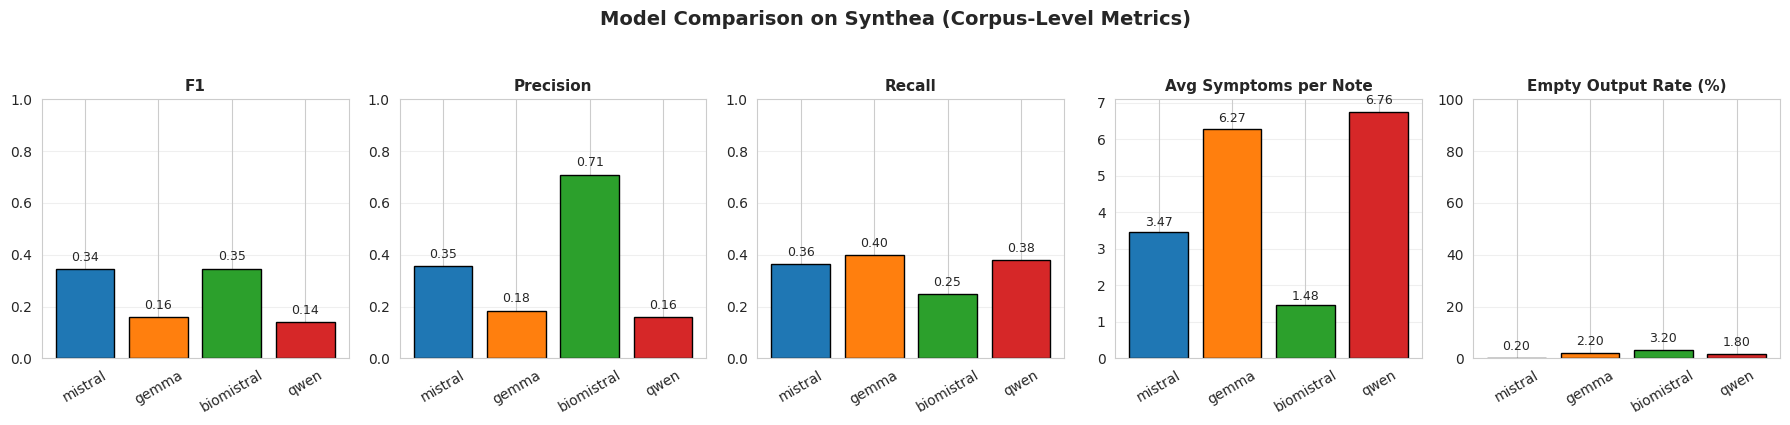

In [19]:
# CELL 18: Small-Multiple Bar Charts (FIXED)
# ====================================================================

import matplotlib.pyplot as plt
import pandas as pd

print("Creating small-multiple bar charts for Synthea metrics...")

# --------------------------------------------------------------------
# PREPARE METRICS (CORPUS-LEVEL ONLY)
# --------------------------------------------------------------------

plot_data = []

for model in models:
    # ✅ FIX: Use summary_df instead of final_results_df
    metrics = summary_df[summary_df['Model'] == model].iloc[0]
    
    pred_df = postprocessed_predictions[model]
    merged = pred_df.merge(gold_df, on='note_id', how='inner')

    avg_symptoms = merged['predictions_postprocessed'].apply(len).mean()
    empty_pct = (
        merged['predictions_postprocessed']
        .apply(lambda x: x == ['none'])
        .sum() / len(merged)
    ) * 100

    plot_data.append({
        'Model': model,
        'F1': metrics['F1'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'Avg Symptoms per Note': avg_symptoms,
        'Empty Output Rate (%)': empty_pct
    })

plot_df = pd.DataFrame(plot_data)

# --------------------------------------------------------------------
# SMALL-MULTIPLE BAR CHARTS
# --------------------------------------------------------------------

metrics_to_plot = [
    ('F1', (0, 1)),
    ('Precision', (0, 1)),
    ('Recall', (0, 1)),
    ('Avg Symptoms per Note', None),
    ('Empty Output Rate (%)', (0, 100))
]

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(metrics_to_plot),
    figsize=(18, 4),
    sharex=True
)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for ax, (metric, ylim) in zip(axes, metrics_to_plot):
    ax.bar(
        plot_df['Model'],
        plot_df[metric],
        color=colors,
        edgecolor='black'
    )

    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)

    if ylim:
        ax.set_ylim(*ylim)

    # Value labels
    for i, value in enumerate(plot_df[metric]):
        ax.text(
            i,
            value + (ylim[1] * 0.02 if ylim else value * 0.02),
            f"{value:.2f}" if value < 10 else f"{value:.1f}",
            ha='center',
            va='bottom',
            fontsize=9
        )

    ax.grid(axis='y', alpha=0.3)

fig.suptitle(
    'Model Comparison on Synthea (Corpus-Level Metrics)',
    fontsize=14,
    fontweight='bold',
    y=1.05
)

plt.tight_layout()
plt.savefig(
    f'{OUTPUT_DIR}/synthea_viz_04_small_multiple_metrics.png',
    dpi=300,
    bbox_inches='tight'
)

print("✓ Saved: synthea_viz_04_small_multiple_metrics.png")
plt.show()

In [20]:
# CELL 19: Create Additional Publication Tables
# ====================================================================

print("Creating publication tables...")

# TABLE 1: Overall Performance (formatted)
table1 = summary_df.merge(diag_df[['Model', 'Avg Symptoms', 'Empty %']], on='Model')
table1_formatted = table1.copy()
table1_formatted['Precision'] = table1_formatted['Precision'].apply(lambda x: f"{x:.3f}")
table1_formatted['Recall'] = table1_formatted['Recall'].apply(lambda x: f"{x:.3f}")
table1_formatted['F1'] = table1_formatted['F1'].apply(lambda x: f"{x:.3f}")
table1_formatted['Avg Symptoms'] = table1_formatted['Avg Symptoms'].apply(lambda x: f"{x:.1f}")
table1_formatted['Empty %'] = table1_formatted['Empty %'].apply(lambda x: f"{x:.1f}%")

table1_formatted = table1_formatted[['Model', 'Precision', 'Recall', 'F1', 'Avg Symptoms', 'Empty %']]
table1_formatted.to_csv(f'{OUTPUT_DIR}/synthea_table1_overall_performance.csv', index=False)
print("✓ Saved: synthea_table1_overall_performance.csv")

# TABLE 2: Error Distribution
error_summary = errors_df.groupby(['model', 'error_type']).size().reset_index(name='count')
error_pivot = error_summary.pivot(index='model', columns='error_type', values='count').fillna(0).reset_index()
error_pivot['Total'] = error_pivot['false_positive'] + error_pivot['false_negative']
error_pivot['FP %'] = (error_pivot['false_positive'] / error_pivot['Total'] * 100).round(1)
error_pivot['FN %'] = (error_pivot['false_negative'] / error_pivot['Total'] * 100).round(1)
error_pivot.columns = ['Model', 'FP Count', 'FN Count', 'Total', 'FP %', 'FN %']
error_pivot[['FP Count', 'FN Count', 'Total']] = error_pivot[['FP Count', 'FN Count', 'Total']].astype(int)

error_pivot.to_csv(f'{OUTPUT_DIR}/synthea_table2_error_distribution.csv', index=False)
print("✓ Saved: synthea_table2_error_distribution.csv")

print("\nTABLE 1: Overall Performance")
print(table1_formatted.to_string(index=False))

print("\nTABLE 2: Error Distribution")
print(error_pivot.to_string(index=False))

Creating publication tables...
✓ Saved: synthea_table1_overall_performance.csv
✓ Saved: synthea_table2_error_distribution.csv

TABLE 1: Overall Performance
     Model Precision Recall    F1 Avg Symptoms Empty %
biomistral     0.709  0.249 0.347          2.0    3.0%
   mistral     0.355  0.363 0.344          3.6    0.0%
     gemma     0.184  0.400 0.160         10.1    0.0%
      qwen     0.160  0.379 0.140         11.1    0.0%

TABLE 2: Error Distribution
     Model  FP Count  FN Count  Total  FP %  FN %
biomistral      1083       612   1695  36.1  63.9
     gemma      1253      4510   5763  78.3  21.7
   mistral      1123      1221   2344  52.1  47.9
      qwen      1278      5050   6328  79.8  20.2


In [21]:
import zipfile
import os

zip_path = "/kaggle/working/synthea_results_selected.zip"

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk("/kaggle/working"):
        for file in files:
            if file.endswith((".csv", ".png", ".json")):
                full_path = os.path.join(root, file)
                zipf.write(full_path, arcname=file)

print(f"✅ Created ZIP: {zip_path}")

✅ Created ZIP: /kaggle/working/synthea_results_selected.zip
